# ___

# [ Machine Learning in Geosciences ]

## **ML Workflow exampl** 

*Author: lukas.brodsky@natur.cuni.cz*

@KAGIK

___


### 1.1 The Problem

TASK: Predict Forest Fires using Meteorological Data

Context: "Forest fires are a major environmental issue, creating economical and ecological damage while endangering human lives. Fast detection is a key element for controlling such phenomenon. To achieve this, one alternative is to use automatic tools based on local sensors, such as provided by meteorological stations. In effect, meteorological conditions (e.g. temperature, wind) are known to influence forest fires and several fire indexes, such as the forest Fire Weather Index (FWI), you can use such features, see below the figure for feature engineering. 
In this work, we explore a Machine Learning (ML) approach to **predict the burned area of forest fires**.


### 1.2 Assumptions

* The problem is a multivariate regression (will use multiple features to make a prediction); 
* There is no continuous flow of data, hence batch learning shall be applied; 
* The meterological data are good indicators of the forest fire; 
* There are enough variables (features) to predict the forest fire. 


### 1.3 Expected results 

* Machine Learning model to predict the burned area of the forest fires based on the meterological data. 
___    

### Weather features

<div>
<img src="attachment:image.png" width="600">
</div>

### Input data atrributes description

**Attribute information**

   1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
   2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
   3. month - month of the year: "jan" to "dec" 
   4. day - day of the week: "mon" to "sun"
   5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
   6. DMC - DMC index from the FWI system: 1.1 to 291.3 
   7. DC - DC index from the FWI system: 7.9 to 860.6 
   8. ISI - ISI index from the FWI system: 0.0 to 56.10
   9. temp - temperature in Celsius degrees: 2.2 to 33.30
   10. RH - relative humidity in %: 15.0 to 100
   11. wind - wind speed in km/h: 0.40 to 9.40 
   12. rain - outside rain in mm/m2 : 0.0 to 6.4 
   13. area - the burned area of the forest (in ha): 0.00 to 1090.84 


#####  Problem definition checklist
    [] What exactly is the target variable y?
    [] What are the input features X?
    [] Is this classification, regression, or another task?
    [] What is the unit of observation (pixel, polygon, time step)?
    [] Is this prediction or explanation?
    [] What assumptions am I making about the process?
    [...] What would a “good” prediction mean in this context?
    [avoid] Is there spatial or temporal structure I must consider?


In [18]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
print('2')

2


In [20]:
# Input data 
url = 'data/forestfires.csv'
data = gpd.read_file(url)
data2 = pd.read_csv(url)

data.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0,0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18,33,0.9,0,0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0,0
3,8,6,mar,fri,91.7,33.3,77.5,9,8.3,97,4,0.2,0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0,0


### 2. Exploratory Data Analysis (EDA) 

<Axes: >

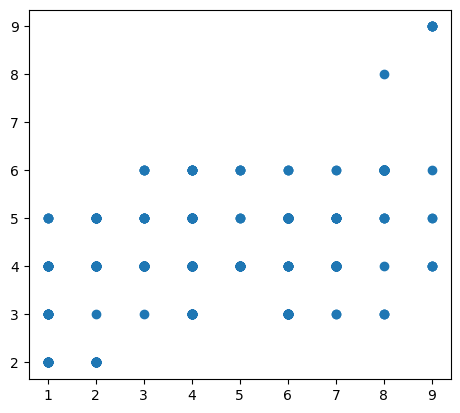

In [4]:
# plot burnd area - spatial plot

from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(data["X"], data["Y"])]

gdf = gpd.GeoDataFrame(data, geometry=geometry)

gdf.plot()

In [5]:
# hist burned area 

fires = data2["area"]
fires.head




<bound method NDFrame.head of 0       0.00
1       0.00
2       0.00
3       0.00
4       0.00
       ...  
512     6.44
513    54.29
514    11.16
515     0.00
516     0.00
Name: area, Length: 517, dtype: float64>

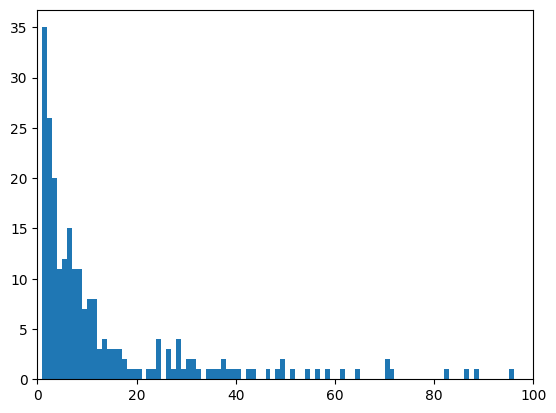

In [6]:
plt.hist(fires,bins=range(1, 500))
plt.xlim(0,100)
plt.show()


In [ ]:
# hist meteo data 


<Axes: >

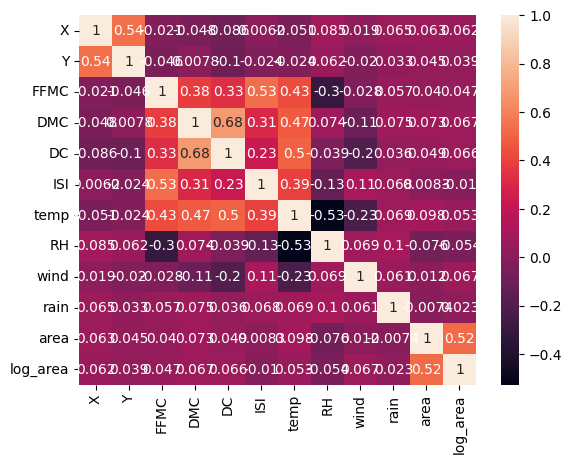

In [7]:
# coreletion betwen features 

num_df = data2.drop(columns=["month", "day"])


num_df["log_area"] = np.log1p(num_df["area"])

corr = num_df.corr()

sns.heatmap(corr, annot=True)

C:\Users\Oleksandr\AppData\Local\Temp\ipykernel_12684\2243285387.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summer_df["is_weekend"] = summer_df["day"].isin(["sat", "sun"])


<Axes: >

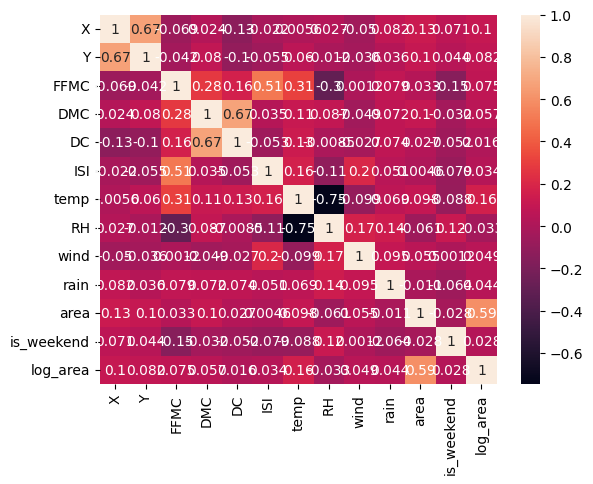

In [8]:
# explore sun sat days  vs fires ???

summer_df = data2[data2["month"].isin(["jun", "jul", "aug"])]

summer_df["is_weekend"] = summer_df["day"].isin(["sat", "sun"])


num_df = summer_df.drop(columns=["month", "day"])

num_df["log_area"] = np.log1p(num_df["area"])

corr = num_df.corr()

sns.heatmap(corr, annot=True)

##### EDA checklist 

    [] What is the distribution of each feature?
    [] Are there missing values? How many?
    [] Are there outliers or unrealistic values?
    [] Is the dataset balanced (for regresion)?  SMOGER
    [] Are features correlated or redundant?
    [] Are there different regimes or clusters in the data?
    [] Does the data reflect real-world variability?
    [avoid] Are there spatial or temporal patterns?


### 3. Data preparation 

In [ ]:
# Convert categorical strings into dummy variables
data_final = pd.get_dummies(data2, columns=['month', 'day'], drop_first=True)

# Define X and y 
X = data_final.drop(['area'], axis=1) # Drop the raw area
y = np.log1p(data_final['area'])      # Use the log transformed target

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Initialize and train
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

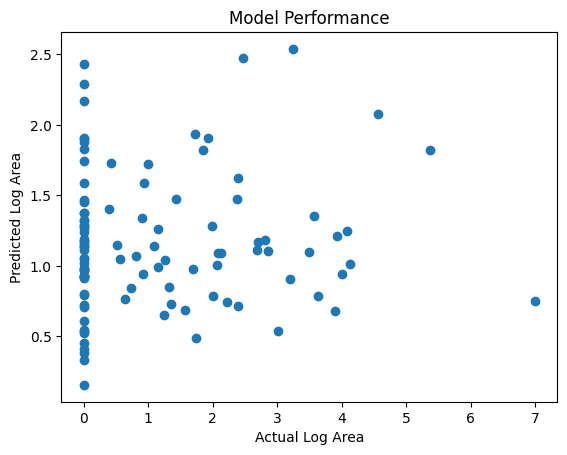

Mean Absolute Error: 1.2061301255467847


In [25]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual Log Area")
plt.ylabel("Predicted Log Area")
plt.title("Model Performance")
plt.show()

print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions)}")

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Log transform the target
data2['log_area'] = np.log1p(data2['area'])

# 2. Convert categories (Month/Day)
data_encoded = pd.get_dummies(data2, columns=['month', 'day'], drop_first=True)

# 3. Define Features and Target
X = data_encoded.drop(['area', 'log_area'], axis=1)
y = data_encoded['log_area']

# 4. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# SMOGER

In [ ]:
# many 0, some areas > 0  up to 1000 ha
# squere riit of burned area?
# look disturbution

In [ ]:
# car values to numerical

In [ ]:
# split: stratified must!

In [ ]:
# scale!

#####  Data Preparation chacklist

    [] Did I split the data before preprocessing?
    [avoid] Is there any data leakage (future info, target leakage)?
    [] Are features scaled/normalized appropriately?
    [] How are missing values handled?
    [] Are categorical variables encoded correctly?
    [] Did I remove irrelevant or redundant features?
    [] Is class imbalance addressed (if needed)?
    [] Is preprocessing reproducible (pipeline)?


    # it is regresion modell!! 


### 4. Select and train model 

In [28]:
# non linear problem BUT i will start with simple multi-variete linear model as baseline 

In [29]:
# next: SVM, Tree-based regresion model (maybe not compare more then 3 models)

In [30]:
pass

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

models = {
    "Linear": LinearRegression(),
    "SVR": SVR(kernel='rbf', C=1.0, epsilon=0.1),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# Iterate and evaluate
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    print(f"{name} MAE: {mean_absolute_error(y_test, preds):.4f}")

Linear MAE: 1.2021
SVR MAE: 1.1661
RandomForest MAE: 1.2102


#####  Data Preparation checklist

    [] What assumption does this model make?
    [] Does the data satisfy this assumption?
    [] Is the model too simple (underfitting risk)?
    [] Is the model too complex (overfitting risk)?
    [] How sensitive is the model to noise?
    [avoid] Does the model handle spatial/temporal structure?
    [] Is the model interpretable if needed?
    [] Am I comparing multiple models or guessing one?


### 5. Model fine-tuning & validation 

In [32]:
from sklearn.model_selection import RandomizedSearchCV

# SVR Space
svr_params = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2, 0.5],
    'gamma': ['scale', 'auto', 0.1, 0.01]
}

# RF Space
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

In [35]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

# 1. Define the parameter grid
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

# 2. Initialize the Base Model
rf = RandomForestRegressor(random_state=42)

# 3. Setup RandomizedSearch
# We use 5-fold CV as you noted in your checklist
n_iter_search = 20 
random_search = RandomizedSearchCV(rf, param_distributions=param_dist,
                                   n_iter=n_iter_search, cv=5, 
                                   scoring='neg_mean_absolute_error',
                                   random_state=42)

# 4. Fit the model
random_search.fit(X_train_scaled, y_train)

# 5. DEFINE 'best_rf'
best_rf = random_search.best_estimator_

print("Best Parameters found:", random_search.best_params_)

Best Parameters found: {'n_estimators': 100, 'min_samples_split': 5, 'max_features': 'log2', 'max_depth': 5}


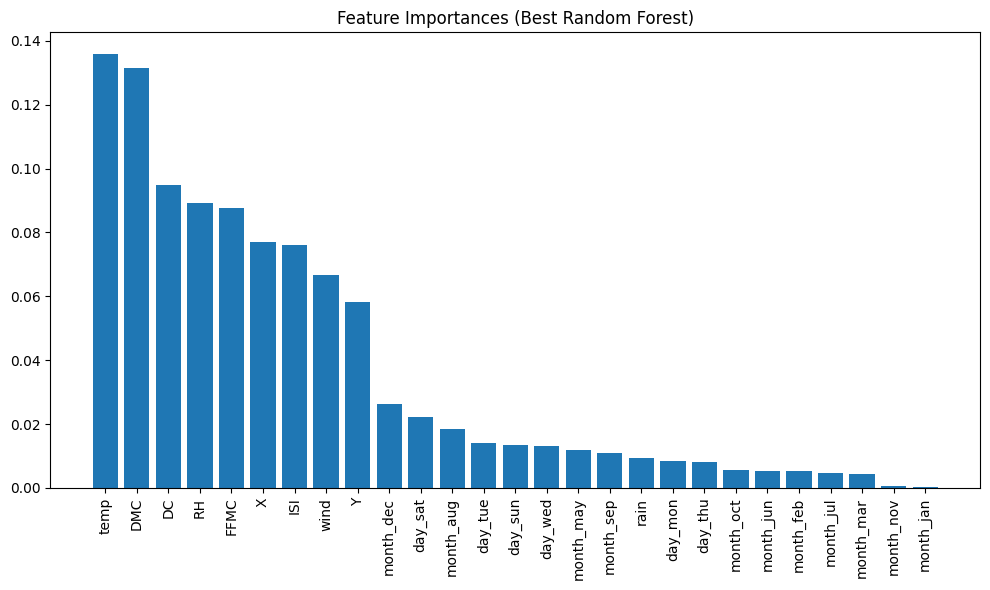

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Get importances
importances = best_rf.feature_importances_
# Use the column names from your encoded dataframe
feature_names = X.columns 

# Sort them
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Best Random Forest)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

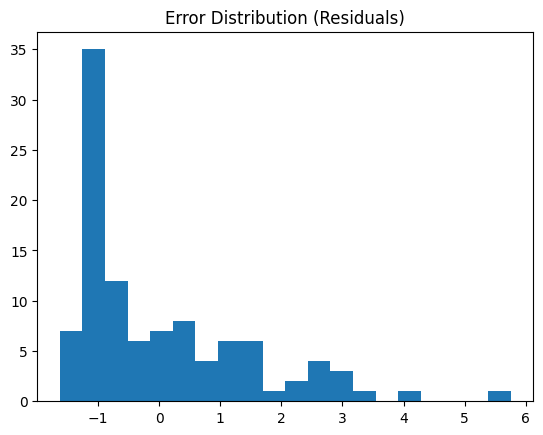

In [38]:
residuals = y_test - best_rf.predict(X_test_scaled)
plt.hist(residuals, bins=20)
plt.title("Error Distribution (Residuals)")
plt.show()

In [ ]:
# RandomizeSearch on limited models a/ SVR and B/ RF 

In [ ]:
# Cross calidation  folds: 5-10 (up to laptop)

In [ ]:
# sensitivity through splits (CV??)

In [ ]:
# MAE

###### Model-finetuning & validation checklist

    [] Is my validation strategy appropriate (CV, spatial CV)?
    [] Is the test set truly unseen?
    [] Am I tuning hyperparameters on validation (not test)?
    [] Are results stable across different splits?
    [] What metric am I optimizing?
    [] Does the metric reflect the real objective?
    [] Am I overfitting during tuning?
    [] Is model performance consistent?


### 6. Results interpretation


In [ ]:
pass 

In [ ]:
pass

In [ ]:
pass 

##### Results interpretation checklist

    [] How good is the model? (metrics)
    [] Where does it fail? (error structure)
    [] Why does it fail? (bias/variance, data)
    [] Does it make sense scientifically?
    [] Can we trust it in real-world use? 
